In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib_venn import venn3_circles
import seaborn as sns
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
import os 
from matplotlib.patches import Patch
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


In [2]:
incident_categories = pd.read_csv('/Users/daniellancet/Desktop/Spring_2026/CANS_Project/UPDATED Incident Matching - Exact_Column_Name_Table.csv')
cans_cleaned = pd.read_csv('/Users/daniellancet/Desktop/Spring_2026/CANS_Project/OneDrive_2_2-7-2026/cans_demo_data.csv', dtype={'OptionsNumber': str}) 
incidents_df = pd.read_excel('//Users/daniellancet/Desktop/Spring_2026/CANS_Project/OneDrive_2_2-7-2026/Incidents Jan 1 2020 to  Dec 31 2025 Demographic Information Revised With County of Service.xlsx', dtype = 'str')
incident_category_path = '/Users/daniellancet/Desktop/Spring_2026/CDSS_170/CANS_Project copy/Novel_Data/UPDATED Incident Matching - Exact_Column_Name_Table.csv'

def incident_cat_cols(incident_category, incident_path = incident_category_path): 
    df = pd.read_csv(incident_path) 
    return df[incident_category].dropna().values

cans_cleaned['DateCompleted'] = cans_cleaned['DateCompleted'].astype('datetime64[ns]')


suicide_related_incidents = incident_cat_cols('Suicide Related Incidents', incident_path=incident_category_path)

cans_cols = [
    'Substance Use','Sleep','Decision Making/Judgment','Family Function','Anxiety',
    'Adjustment To Trauma','Social Functioning','Living Situation',
    'Oppositional','Depression','Sexual Development','Conduct',
    'Impulsivity/Hyperactivity','Developmental/Intellectual','Anger Control',
    'Psychosis','School Attendance','School Behavior','School Achievement',
    'Intentional Misbehavior/Social Behavior','Other Self Harm (Recklessness)',
    'Non-Suicidal Self Injurious Behavior','Danger To Others','Suicide Risk',
    'Sexual Aggression','Runaway','Educational','Family Strengths','Talents/Interests',
    'Natural Supports','Delinquent Behavior','Interpersonal','Community Life/Connection',
    'Spiritual/Religious','Knowledge','Involvement With Care','Social Resources',
    'Supervision','Medical/Physical Health','Developmental','Mental Health',
    'Residential Stability','Safety'
]

# min_date = cans_cleaned['DateCompleted'].min()
# max_date = cans_cleaned['DateCompleted'].max()


# ops_numbers = cans_cleaned.groupby('OptionsNumber')['DateCompleted'].agg(lambda x: x.max() - x.min())

# ops_numbers = cans_cleaned.groupby('OptionsNumber')


In [3]:
from Scripts.get_all_data import read_dfs, build_new_dfs
folder_path = '/Users/daniellancet/Desktop/Spring_2026/CDSS_170/CANS_Project copy/Aspiranet_Data'
incident_category_path = '/Users/daniellancet/Desktop/Spring_2026/CDSS_170/CANS_Project copy/Novel_Data/UPDATED Incident Matching - Exact_Column_Name_Table.csv'

dfs = read_dfs(folder_path=folder_path)
all_dfs = build_new_dfs(dfs=dfs)

Found 3 data files. Loading...
Duplicates Removed: 2836
Excluded 591 rows: invalid QuestionKey, missing ChoiceValue, or non-max ChoiceValue within group
1. Initial top_n count: 45
2. Count after removing Index columns: 43
3. Degenerate rows excluded: 48
5. All features have variance.


**Data Range**: ('2020-01-02', '2025-12-19')


**Time observed (max datecompleted - min datecompleted)**

count                           1062

mean     236 days 19:15:15.254237288

std      286 days 11:58:25.808663564

min                  0 days 00:00:00

25%                 41 days 00:00:00

50%                159 days 00:00:00

75%                329 days 00:00:00

max               2088 days 00:00:00





Qualties: 
 - Time varying covariates (each new assessment). 
 - Semi Iregular assessment timing (median, 75th percentile gap is 90 days but with significant variance). 
 - Exact dates of incidents which can happen to the same individual multiple times (even multiple times between incidents, not cleanly a survival problem where if an event occurs there are no more further events) 
 - Still a form of time to event data. 
 - Best model to use to understand the relationship between the CANS assessment data and the incidents given the structure of the data. 

In [5]:
def make_hazard_table(cans_df, incidents_df, incident_list,
                      admin_censor_date="2025-12-31", max_gap_days=180, filter_interval= True, filter_amount = 200):
    """
    Construct a hazard table for survival analysis suitable for lifelines CoxPHFitter.
    Durations are numeric floats (days since first assessment per person).
    
    Parameters
    ----------
    cans_df : pd.DataFrame
        CANS assessment data with at least ['OptionsNumber', 'DateCompleted'].
    incidents_df : pd.DataFrame
        Incident data with ['OptionsNumber', 'IncidentType', 'IncidentDate'].
    incident_list : list of str
        Incident types to include as the "event".
    admin_censor_date : str or pd.Timestamp
        Administrative censor date (used to fill last assessment interval).
    max_gap_days : int
        Maximum days allowed between assessments before considering censoring.
    
    Returns
    -------
    pd.DataFrame
        Hazard-table-ready DataFrame with numeric durations and binary events:
        ['OptionsNumber', 'DateCompleted', 'start', 'stop', 'start_days', 'stop_days',
         'event', 'days_since_last_assessment', 'days_since_last_incident']
    """
    
    incidents_sub = incidents_df[incidents_df['IncidentType'].isin(incident_list)].copy()
    incidents_sub['IncidentDate'] = pd.to_datetime(incidents_sub['IncidentDate'])
    incident_dict = incidents_sub.groupby('OptionsNumber')['IncidentDate'].apply(list).to_dict()
    
    cans = cans_df.copy()
    cans['DateCompleted'] = pd.to_datetime(cans['DateCompleted'])
    cans = cans.sort_values(['OptionsNumber', 'DateCompleted'])
    
    cans['Next_Assessment'] = cans.groupby('OptionsNumber')['DateCompleted'].shift(-1)
    
    admin_censor_date = pd.Timestamp(admin_censor_date)
    max_followup = cans['DateCompleted'] + pd.Timedelta(days=max_gap_days)
    
    cans['Next_Assessment'] = cans['Next_Assessment'].fillna(
        pd.Series(np.minimum(max_followup.values.astype('int64'), admin_censor_date.value))
        .astype('datetime64[ns]')
    )
    
    cans['start'] = cans['DateCompleted']
    cans['stop']  = cans['Next_Assessment']

    def get_event(row):
        """Return first incident date in interval and binary event."""
        incidents = incident_dict.get(row['OptionsNumber'], [])
        interval_incidents = [d for d in incidents if row['start'] < d <= row['stop']]
        if not interval_incidents:
            return pd.Series([pd.NaT, 0])
        return pd.Series([min(interval_incidents), 1])
    
    cans[['event_date', 'event']] = cans.apply(get_event, axis=1)

    origin = cans.groupby('OptionsNumber')['start'].transform('min')
    cans['start_days'] = (cans['start'] - origin).dt.total_seconds() / 86400
    cans['stop_days']  = (cans['event_date'].fillna(cans['stop']) - origin).dt.total_seconds() / 86400
    
    cans['start_days'] = cans['start_days'].astype(float)
    cans['stop_days']  = cans['stop_days'].astype(float)
    cans['event']      = cans['event'].astype(int)
    
    cans['days_since_last_assessment'] = cans.groupby('OptionsNumber')['DateCompleted']\
                                             .diff().dt.days.fillna(0)
    
    def days_since_last_incident(row):
        incidents = incident_dict.get(row['OptionsNumber'], [])
        past_incidents = [d for d in incidents if d <= row['start']]
        if len(past_incidents) == 0:
            return np.nan
        return (row['start'] - past_incidents[-1]).days
    
    cans['days_since_last_incident'] = cans.apply(days_since_last_incident, axis=1)

    hazard_table = cans

    if filter_interval:
        hazard_table = hazard_table[hazard_table['stop_days'] - hazard_table['start_days'] <= filter_amount]
    
    return hazard_table


def build_full_hazard_table(
        incident_cat_dict,
        cans_df,
        incidents_df,
        base_table,
        admin_censor_date="2025-12-31",
        max_gap_days=180,
        filter_interval=True,
        filter_amount=200):
    """ 
    Adds incident event_date, event indicator, stop_days, 
    and days since last incident for all incident catgories to one master table
    which can then be used to apply Cox Proportional Hazards model to each incident category seperately 
    """

    for incident_cat, incident_cat_lst in incident_cat_dict.items():

        hazard_table = make_hazard_table(
            cans_df=cans_df,
            incidents_df=incidents_df,
            incident_list=incident_cat_lst,
            admin_censor_date=admin_censor_date,
            max_gap_days=max_gap_days,
            filter_interval=filter_interval,
            filter_amount=filter_amount
        )

        incident_h_table = hazard_table[
            ['OptionsNumber','DateCompleted','event_date','event','stop_days', 'days_since_last_incident']
        ]

        rename_cols = {
            c: f"{incident_cat}_{c}"
            for c in [
                        'event_date',
                        'event',
                        'stop_days',
                        'days_since_last_incident'
                        ]
        }

        incident_h_table = incident_h_table.rename(columns=rename_cols)

        base_table = base_table.merge(
            incident_h_table,
            on=['OptionsNumber','DateCompleted'],
            how='left'
        )

    return base_table


In [13]:
def build_full_hazard_table(
        incident_cat_dict,
        cans_df,
        incidents_df,
        base_table,
        admin_censor_date="2025-12-31",
        max_gap_days=180,
        filter_interval=True,
        filter_amount=200):
    

    for incident_cat, incident_cat_lst in incident_cat_dict.items():

        hazard_table = make_hazard_table(
            cans_df=cans_df,
            incidents_df=incidents_df,
            incident_list=incident_cat_lst,
            admin_censor_date=admin_censor_date,
            max_gap_days=max_gap_days,
            filter_interval=filter_interval,
            filter_amount=filter_amount
        )

        incident_h_table = hazard_table[
            ['OptionsNumber','DateCompleted','event_date','event','stop_days', 'days_since_last_incident']
        ]

        rename_cols = {
            c: f"{incident_cat}_{c}"
            for c in [
                        'event_date',
                        'event',
                        'stop_days',
                        'days_since_last_incident'
                        ]
        }

        incident_h_table = incident_h_table.rename(columns=rename_cols)

        base_table = base_table.merge(
            incident_h_table,
            on=['OptionsNumber','DateCompleted'],
            how='left'
        )

    return base_table

In [ ]:
base_hazard_table = make_hazard_table(cans_df=cans_cleaned, incidents_df=incidents_df, incident_list=suicide_related_incidents, filter_amount=5000) # could be any incident list
incident_cat_dict = {inc_cat.replace('/', '_').replace(' ', '_').replace('__', '_'): incident_cat_cols(incident_category=inc_cat, incident_path = incident_category_path) for inc_cat in incident_categories.columns}
incident_cols = [
    'event_date',
    'event',
    'stop_days',
    'days_since_last_incident'
]
keep_cols = [c for c in base_hazard_table.columns if c not in incident_cols]
base_table = base_hazard_table[keep_cols]
full_hazard_table = build_full_hazard_table(incident_cat_dict, cans_df=cans_cleaned, incidents_df=incidents_df, base_table = base_table, max_gap_days=200)


# Correlational Analysis

In [123]:
def bootstrap_correlations(incident, incidents_df = incidents_df, cans_df = cans_cleaned, incident_category_path = incident_category_path, N = 10000):
    
    incidents = incident_cat_cols(incident, incident_category_path)
    hazard_table = make_hazard_table(cans_df=cans_cleaned, incidents_df=incidents_df, incident_list=incidents) 
    np.random.seed(100)

    
    correlation_dict = {col: [] for col in cans_cols}

    people = hazard_table['OptionsNumber'].unique()
    n_people = len(people)

    for _ in range(N):

        sampled_people = np.random.choice(people, size=n_people, replace=True)
        
        sample_df = hazard_table[hazard_table['OptionsNumber'].isin(sampled_people)].copy()

        person_summary = sample_df.groupby('OptionsNumber')[['event'] + cans_cols].mean()
        

        corr = person_summary.corr()['event']

        for col in cans_cols:
            correlation_dict[col].append(corr[col])
    
    return correlation_dict

def incident_correlation_table(incident_type):
    
    corrs = bootstrap_correlations(incident_type)
    corr_means = []
    corr_lower_sd = []
    corr_upper_sd = []


    for incident_cat in corrs.keys(): 
        corr_sims = corrs[incident_cat]
        
        mean_corr = np.mean(corr_sims)
        corr_means.append(mean_corr)

        sd_corr = np.std(corr_sims)

        conf_interval_lower = mean_corr - 2*sd_corr
        corr_lower_sd.append(conf_interval_lower)

        conf_interval_upper = mean_corr + 2*sd_corr
        corr_upper_sd.append(conf_interval_upper)

    df = pd.DataFrame({
        'CANS Score': corrs.keys(),
        'Correlation': np.round(corr_means, 3),
        "CI Lower": np.round(corr_lower_sd, 3),
        "CI Upper": np.round(corr_upper_sd, 3)
    })

    df['Bootstrapped 95% CI'] = df.apply(lambda row: [row['CI Lower'], row['CI Upper']], axis=1)

    df = df.drop(columns=['CI Lower', 'CI Upper'])

    df = df.sort_values('Correlation', ascending=False).reset_index().drop(columns=['index'])

    return df



def visualize_correlation(cans_score, corrs=corrs):

    dist = np.array(corrs[cans_score])

    mean = dist.mean()
    sd = dist.std() * 2

    lower = mean - sd
    upper = mean + sd

    plt.figure(figsize=(7,5))

    counts, bins, patches = plt.hist(
        dist, bins=30, density=True, alpha=0.8, edgecolor='black'
    )

    for patch, left, right in zip(patches, bins[:-1], bins[1:]):
        center = (left + right) / 2
        if lower <= center <= upper:
            patch.set_facecolor('gold')
        else:
            patch.set_facecolor('lightblue')


    legend_items = [
        Patch(facecolor='gold', label='Within ±2 SD'),
        Patch(facecolor='blue', label='Outside ±2 SD'),
        Patch(facecolor='none', edgecolor='none', label=f"Mean = {mean:.3f}"),
        Patch(facecolor='none', edgecolor='none', label=f"±2 SD = {sd:.3f}")
    ]

    plt.title(f"{cans_score} Correlation Bootstrapped Distribution")
    plt.xlabel("Correlation")
    plt.ylabel("Density")
    plt.legend(handles=legend_items)

    plt.show()


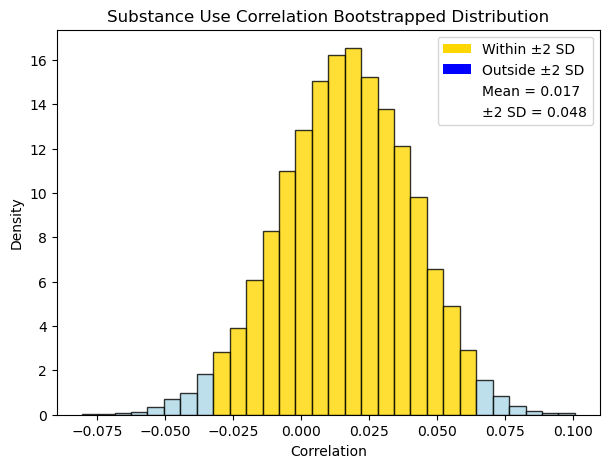

In [132]:
corrs = bootstrap_correlations('Self_Harm')
corr_table = incident_correlation_table('Self_Harm')
indiviual_cans_corr_dist_vis = visualize_correlation('Substance Use')

In [133]:
corr_table

,CANS Score,Correlation,Bootstrapped 95% CI
0,Suicide Risk,0.257,"[0.186, 0.328]"
1,Non-Suicidal Self Injurious Behavior,0.239,"[0.166, 0.311]"
2,Depression,0.159,"[0.118, 0.201]"
3,Anxiety,0.109,"[0.065, 0.154]"
4,Runaway,0.099,"[0.029, 0.17]"
5,Impulsivity/Hyperactivity,0.077,"[0.027, 0.127]"
6,Safety,0.075,"[0.027, 0.124]"
7,Other Self Harm (Recklessness),0.072,"[0.017, 0.128]"
8,Adjustment To Trauma,0.068,"[0.02, 0.115]"
9,Substance Use,0.063,"[0.004, 0.123]"
